 # OBO using ATSC

In [1]:
library("evaluomeR")
library("dplyr")
library("ggplot2")
library("ggrepel")
library("reshape2")

options(scipen=10)
options(repr.plot.width=12, repr.plot.height=12)

Cargando paquete requerido: SummarizedExperiment

Cargando paquete requerido: MatrixGenerics

Cargando paquete requerido: matrixStats


Adjuntando el paquete: 'MatrixGenerics'


The following objects are masked from 'package:matrixStats':

    colAlls, colAnyNAs, colAnys, colAvgsPerRowSet, colCollapse,
    colCounts, colCummaxs, colCummins, colCumprods, colCumsums,
    colDiffs, colIQRDiffs, colIQRs, colLogSumExps, colMadDiffs,
    colMads, colMaxs, colMeans2, colMedians, colMins, colOrderStats,
    colProds, colQuantiles, colRanges, colRanks, colSdDiffs, colSds,
    colSums2, colTabulates, colVarDiffs, colVars, colWeightedMads,
    colWeightedMeans, colWeightedMedians, colWeightedSds,
    colWeightedVars, rowAlls, rowAnyNAs, rowAnys, rowAvgsPerColSet,
    rowCollapse, rowCounts, rowCummaxs, rowCummins, rowCumprods,
    rowCumsums, rowDiffs, rowIQRDiffs, rowIQRs, rowLogSumExps,
    rowMadDiffs, rowMads, rowMaxs, rowMeans2, rowMedians, rowMins,
    rowOrderStats, rowProds, rowQuantiles,

# Install evaluomeR 1.8.1

In [2]:
#install.packages("devtools")
#library(devtools)
#devtools::install_github("neobernad/evaluomeR@v1.8.1")

In [3]:
getRversion()
packageVersion("evaluomeR")

[1] '4.4.1'

[1] '1.8.1'

# Dataset <a class="anchor" id="dataset"></a>

In [4]:
seed = 13606
k.range = c(3,10)
cbi = "kmeans" # Run evaluomeR::evaluomeRSupportedCBI() to get available clustering techniques
alpha = NULL # If NULL, then get best alpha until max_alpha is run
max_alpha = 0.2 # Default 0.1

In [5]:
data("ontMetricsOBO")
dataset = ontMetricsOBO
head(dataset)

,Description,ANOnto,AROnto,CBOOnto,CBOOnto2,CROnto,DITOnto,INROnto,LCOMOnto,NACOnto,NOCOnto,NOMOnto,POnto,PROnto,RFCOnto,RROnto,TMOnto,TMOnto2,WMCOnto,WMCOnto2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AEO,0.9920319,0.000000,1.0677291,1.0677291,0.003984064,13,1.0677291,6.258065,1.089744,2.821053,0.4462151,1.0637450,0.2947368,1.5139442,0.7052632,0.068000000,2.117647,7.461538,1.192308
2,AGRO,0.9907407,3.101852,1.0694444,1.0694444,0.363425926,16,1.0694444,7.695971,1.052174,2.287129,1.2037037,1.0555556,0.5295316,2.2731481,0.4704684,0.062645012,2.148148,9.134783,1.186957
3,APO,1.0263930,0.000000,1.0000000,1.0000000,0.002932551,9,1.0000000,3.914179,1.003745,4.608108,0.0000000,0.8914956,0.0000000,1.0000000,1.0000000,0.002941176,2.000000,3.928839,1.003745
4,BCO,1.2913386,3.503937,1.0157480,1.0157480,0.212598425,8,1.0157480,4.602151,1.022222,3.486486,3.2677165,1.0078740,0.7628676,4.2834646,0.2371324,0.047619048,2.000000,4.755556,1.033333
5,BFO,0.9722222,0.000000,0.9722222,0.9722222,0.000000000,7,0.9722222,4.904762,1.000000,2.333333,0.0000000,0.9444444,0.0000000,0.9722222,1.0000000,0.000000000,0.000000,4.904762,1.000000
6,BSPO,1.0948905,0.000000,1.3357664,1.3357664,0.007299270,5,1.3357664,2.968944,1.302083,4.463415,1.2335766,0.8978102,0.4801136,2.5693431,0.5198864,0.000000000,0.000000,4.979167,1.677083


In [6]:
dataset_clean = evaluomeR::cleanDataset(dataset, correlation_threshold=1)
pca_suitability = evaluomeR::PCASuitability(dataset_clean$R, sig_level = 0.05)
dataset = dataset_clean$dataset

if (pca_suitability$pca_suitable) {
    r_pca = evaluomeR::performPCA(dataset = dataset)
    dataset = r_pca$dataset_ncp
    evaluomeR::plotPCA_fviz_screeplot(r_pca$pca)
    evaluomeR::plotPCA_fviz_biplot(r_pca$pca)
}
head(dataset)

Preprocessing dataset

Removing non-numeric columns...

	Columns are numeric

Removing correlations...

	Removing correlated column: CBOOnto

	Removing correlated column: PROnto

Checking PCA suitability...

Warning message in log(detR):
"Se han producido NaNs"
	PCA is not suitable. Bartlett's test produced NA for p-value.



,Description,ANOnto,AROnto,CBOOnto2,CROnto,DITOnto,INROnto,LCOMOnto,NACOnto,NOCOnto,NOMOnto,POnto,RFCOnto,RROnto,TMOnto,TMOnto2,WMCOnto,WMCOnto2
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
1,AEO,0.9920319,0.000000,1.0677291,0.003984064,13,1.0677291,6.258065,1.089744,2.821053,0.4462151,1.0637450,1.5139442,0.7052632,0.068000000,2.117647,7.461538,1.192308
2,AGRO,0.9907407,3.101852,1.0694444,0.363425926,16,1.0694444,7.695971,1.052174,2.287129,1.2037037,1.0555556,2.2731481,0.4704684,0.062645012,2.148148,9.134783,1.186957
3,APO,1.0263930,0.000000,1.0000000,0.002932551,9,1.0000000,3.914179,1.003745,4.608108,0.0000000,0.8914956,1.0000000,1.0000000,0.002941176,2.000000,3.928839,1.003745
4,BCO,1.2913386,3.503937,1.0157480,0.212598425,8,1.0157480,4.602151,1.022222,3.486486,3.2677165,1.0078740,4.2834646,0.2371324,0.047619048,2.000000,4.755556,1.033333
5,BFO,0.9722222,0.000000,0.9722222,0.000000000,7,0.9722222,4.904762,1.000000,2.333333,0.0000000,0.9444444,0.9722222,1.0000000,0.000000000,0.000000,4.904762,1.000000
6,BSPO,1.0948905,0.000000,1.3357664,0.007299270,5,1.3357664,2.968944,1.302083,4.463415,1.2335766,0.8978102,2.5693431,0.5198864,0.000000000,0.000000,4.979167,1.677083


# evaluomeR - (ATSC) optimal $k$ analysis <a class="anchor" id="evaluomeR"></a>

In [7]:
r_atsc = evaluomeR::ATSC(data=dataset, k.range=k.range, cbi=cbi, alpha=alpha, 
                         max_alpha=max_alpha, gold_standard=NULL, seed=seed)

Computing optimal k value with 'kmeans'



Data loaded.
Number of rows: 119
Number of columns: 18



Processing all metrics, 'merge', in dataframe (17)

	Calculation of k = 3

	Calculation of k = 4

	Calculation of k = 5

	Calculation of k = 6

	Calculation of k = 7

	Calculation of k = 8

	Calculation of k = 9

	Calculation of k = 10



Data loaded.
Number of rows: 119
Number of columns: 18



Processing all metrics, 'merge', in dataframe (17)

	Calculation of k = 3

	Calculation of k = 4

	Calculation of k = 5

	Calculation of k = 6

	Calculation of k = 7

	Calculation of k = 8

	Calculation of k = 9

	Calculation of k = 10

Processing metric: all_metrics


	Maximum stability and quality values matches the same K value: '3'


Optimal k: 3

Determining best L1 and alpha parameter automatically, it might take a while...

Computing best L1 boundry with 'sparcl::KMeansSparseCluster.permute'

Best L1 found is: 2

Running stability and quality indexes with alpha=0 k=3 L1=2

Running stabili

In [8]:
print(paste0("ATSC Optimal k: ", r_atsc$optimalK_ATSC))
print(paste0("Best L1 boundry found: ", r_atsc$L1))
print(paste0("Best alpha found: ", r_atsc$alpha))
if (!is.null(r_atsc$gold_standard_trimmed)) {
    print(paste0("Gold standard vector trimmed, current values are:"))
    print(gold_standard_vector)
    print("After:")
    print(r_atsc$gold_standard_trimmed)
    gold_standard_vector = r_atsc$gold_standard_trimmed
}

[1] "ATSC Optimal k: 3"
[1] "Best L1 boundry found: 2"
[1] "Best alpha found: 0"


## Stability <a class="anchor" id="evaluomeR_stab_plot"></a>

Stability without ATSC and with ATSC

In [9]:
stab = r_atsc$stab
rownames(stab) = c(paste0("stab_", cbi))
stab$Metric = rownames(stab)
stab$Method = "without ATSC"
stab_melt = melt(stab, id.vars = c("Metric", "Method"))

stab_ATSC = r_atsc$stab_ATSC
rownames(stab_ATSC) = c(paste0("stab_", "ATSC"))
stab_ATSC$Metric = rownames(stab_ATSC)
stab_ATSC$Method = "with ATSC"
stab_ATSC_melt = melt(stab_ATSC, id.vars = c("Metric", "Method"))

In [10]:
stab

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_kmeans,0.8187093,0.7718743,0.8060588,0.752566,0.7583944,0.7236281,0.7072628,0.6889604,stab_kmeans,without ATSC


In [11]:
stab_ATSC

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_ATSC,0.8187093,0.7718743,0.8060588,0.752566,0.7583944,0.7236281,0.7072628,0.6889604,stab_ATSC,with ATSC


## Quality <a class="anchor" id="evaluomeR_qual_plot"></a>

Quality without ATSC and with ATSC

In [12]:
qual = r_atsc$qual
rownames(qual) = c(paste0("qual_", cbi))
qual$Metric = rownames(qual)
qual$Method = "without ATSC"
qual_melt = melt(qual, id.vars = c("Metric", "Method"))

qual_ATSC = r_atsc$qual_ATSC
rownames(qual_ATSC) = c(paste0("qual_", "ATSC"))
qual_ATSC$Metric = rownames(qual_ATSC)
qual_ATSC$Method = "with ATSC"
qual_ATSC_melt = melt(qual_ATSC, id.vars = c("Metric", "Method"))

In [13]:
qual

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_kmeans,0.8373045,0.7395661,0.7363499,0.7129011,0.5117377,0.396014,0.4031264,0.4162273,qual_kmeans,without ATSC


In [14]:
qual_ATSC

,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_ATSC,0.8373045,0.7395661,0.7363499,0.7129011,0.5117377,0.396014,0.4031264,0.4162273,qual_ATSC,with ATSC


In [15]:
print(paste0("Stabilities and qualities per k with '", cbi, "' as clustering method"))
stab
qual
print(paste0("Stabily in k=", r_atsc$optimalK,": ", stab[paste0("k_",r_atsc$optimalK)]))
print(paste0("Quality in k=", r_atsc$optimalK,": ", qual[paste0("k_",r_atsc$optimalK)]))

[1] "Stabilities and qualities per k with 'kmeans' as clustering method"


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_kmeans,0.8187093,0.7718743,0.8060588,0.752566,0.7583944,0.7236281,0.7072628,0.6889604,stab_kmeans,without ATSC


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_kmeans,0.8373045,0.7395661,0.7363499,0.7129011,0.5117377,0.396014,0.4031264,0.4162273,qual_kmeans,without ATSC


[1] "Stabily in k=3: 0.818709322776759"
[1] "Quality in k=3: 0.837304516241741"


In [16]:
print(paste0("Stabilities and qualities per k with 'ATSC' as clustering method"))
stab_ATSC
qual_ATSC
print(paste0("Stabily in k=", r_atsc$optimalK_ATSC,": ", stab_ATSC[paste0("k_",r_atsc$optimalK_ATSC)]))
print(paste0("Quality in k=", r_atsc$optimalK_ATSC,": ", qual_ATSC[paste0("k_",r_atsc$optimalK_ATSC)]))

[1] "Stabilities and qualities per k with 'ATSC' as clustering method"


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
stab_ATSC,0.8187093,0.7718743,0.8060588,0.752566,0.7583944,0.7236281,0.7072628,0.6889604,stab_ATSC,with ATSC


,k_3,k_4,k_5,k_6,k_7,k_8,k_9,k_10,Metric,Method
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
qual_ATSC,0.8373045,0.7395661,0.7363499,0.7129011,0.5117377,0.396014,0.4031264,0.4162273,qual_ATSC,with ATSC


[1] "Stabily in k=3: 0.818709322776759"
[1] "Quality in k=3: 0.837304516241741"


# Clusters

In [17]:
# Internal method used to group individuals per cluster
individuals_per_cluster = function(qualityResult) {
    
  qual_df = as.data.frame(assay(qualityResult))
    

  cluster_pos_str = as.character(unlist(qual_df["Cluster_position"]))
  cluster_labels_str = as.character(unlist(qual_df["Cluster_labels"]))

  cluster_pos = as.list(strsplit(cluster_pos_str, ",")[[1]])
  cluster_labels = as.list(strsplit(cluster_labels_str, ",")[[1]])

  individuals_in_cluster = as.data.frame(cbind(cluster_labels, cluster_pos))
  colnames(individuals_in_cluster) = c("Individual", "Cluster")

  return(individuals_in_cluster)
}

In [18]:
dataset = r_atsc$trimmmedDataset
qual_range = qualityRange(data=dataset, k.range=k.range, 
                            all_metrics=TRUE, seed=seed,
                            cbi=cbi)
optimal_k = r_atsc$optimalK_ATSC
cluster_individuals = individuals_per_cluster(assay(qual_range[paste0("k_",optimal_k)]))
print(paste0("CBI: ", cbi, " - k: ", optimal_k))
for (cluster_i in 1:optimal_k) {
    ind_in_cluster = paste(unlist(cluster_individuals[cluster_individuals$Cluster == cluster_i, ]["Individual"]), collapse = ",")
    print(paste("Cluster", cluster_i, ":", ind_in_cluster))
    print("")
}



Data loaded.
Number of rows: 119
Number of columns: 18



Processing all metrics, 'merge', in dataframe (17)

	Calculation of k = 3

	Calculation of k = 4

	Calculation of k = 5

	Calculation of k = 6

	Calculation of k = 7

	Calculation of k = 8

	Calculation of k = 9

	Calculation of k = 10



[1] "CBI: kmeans - k: 3"
[1] "Cluster 1 : CHEBI,CL,CLO,FYPO,GO,NBO,PCO,UPHENO"
[1] ""
[1] "Cluster 2 : AEO,AGRO,APO,BCO,BFO,BSPO,BTO,CARO,CDAO,CEPH,CHEMINF,CHMO,CIO,CMO,CTENO,DDANAT,DDPHENO,DIDEO,DOID,DPO,ECO,EHDAA2,EMAP,EMAPA,ENVO,ERO,EXO,FAO,FBBI,FBBT,FBCV,FBDV,FIX,FLOPO,FMA,FOODON,GENEPIO,GEO,HAO,HOM,HP,HSAPDV,IAO,ICO,IDO,IDOMAL,KISAO,MA,MAMO,MFMO,MI,MICRO,MIRNAO,MIRO,MMO,MMUSDV,MOD,MOP,MP,MPATH,MRO,MS,NCBITAXON,NCIT,NCRO,OAE,OBA,OBCS,OBI,OBIB,OGMS,OMIABIS,OMP,OOSTT,OPL,OVAE,PATO,PO,PORO,PR,PW,REX,RO,RS,RXNO,SBO,SEP,SIBO,SO,SPD,STATO,SWO,SYMP,TADS,TGMA,TO,TTO,UBERON,UO,VARIO,VO,VT,VTO,WBBT,WBLS,WBPHENOTYPE,XAO,XCO,ZECO,ZFA"
[1] ""
[1] "Cluster 3 : OMIT"
[1] ""


# PCA <a class="anchor" id="pca"></a>
We employ Principal Component Analysis (PCA) as a dimensionality reduction technique to facilitate the visualization of clusters within our dataset. PCA allow us to transform the original high-dimensional data into a lower-dimensional space, while preserving as much of the variability as possible.

In [19]:
dataset["Cluster"] = as.factor(as.numeric(cluster_individuals$Cluster))
if (pca_suitability$pca_suitable) {
    pca_df = dataset
} else {
    pca_matrix = dataset %>% select(-Cluster)
    r_pca = evaluomeR::performPCA(dataset = pca_matrix)
    pca_df = r_pca$dataset_ncp
    pca_df$Cluster <- as.factor(dataset$Cluster)
    pca_df$Description <- dataset$Description
}
head(pca_df)

Parameter 'npc' is null. Computing number of factors automatically:

Number of factors, 'ncp' used is: 6



,Description,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Cluster
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>
1,AEO,-0.6556637,-0.5987825,0.1700464,0.1626304,0.17341109,-0.4074420,2
2,AGRO,-0.1757690,0.6815174,0.6107645,-0.4288521,1.83016879,-1.0683859,2
3,APO,-1.4039594,-1.0185104,-0.8209408,0.2958530,0.06426622,-0.5614827,2
4,BCO,-0.9496853,1.8904358,0.6628314,1.3061307,1.38139264,-0.4946740,2
5,BFO,-1.7272519,-0.8127451,-1.5793145,-0.3307977,0.32780559,0.6757711,2
6,BSPO,-0.8436998,0.6469857,-1.5350258,0.8490377,0.05064598,0.8837666,2


In [20]:
# Creating shapes for individuals
pca_df <- pca_df %>%
  mutate(
    # Extract the letter from the Description column
    Letter = Description,
  )

In [21]:
tail(pca_df)

,Description,Dim.1,Dim.2,Dim.3,Dim.4,Dim.5,Dim.6,Cluster,Letter
,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<chr>
114,WBLS,-1.7586629,1.698298,-1.78119920,1.0772781,-0.74545000,-0.6225023,2,WBLS
115,WBPHENOTYPE,-0.1327769,-1.515021,0.32967855,-0.1083398,-0.10518004,-0.1779843,2,WBPHENOTYPE
116,XAO,-0.9674973,1.483815,0.35607754,0.7284598,0.18418121,-0.4113803,2,XAO
117,XCO,-0.5080146,-1.230969,0.03507458,0.5969775,-0.19369809,-0.3680079,2,XCO
118,ZECO,-1.1772512,-1.094691,-0.46688301,0.1547928,0.09568836,-0.4897277,2,ZECO
119,ZFA,-0.7656100,1.346342,0.56787345,0.5739501,0.23055470,-0.3274461,2,ZFA


Too few points to calculate an ellipse
Warning message:
"The following aesthetics were dropped during statistical transformation: label.
ℹ This can happen when ggplot fails to infer the correct grouping structure in
  the data.
ℹ Did you forget to specify a `group` aesthetic or to convert a numerical
  variable into a factor?"
Warning message:
"ggrepel: 114 unlabeled data points (too many overlaps). Consider increasing max.overlaps"


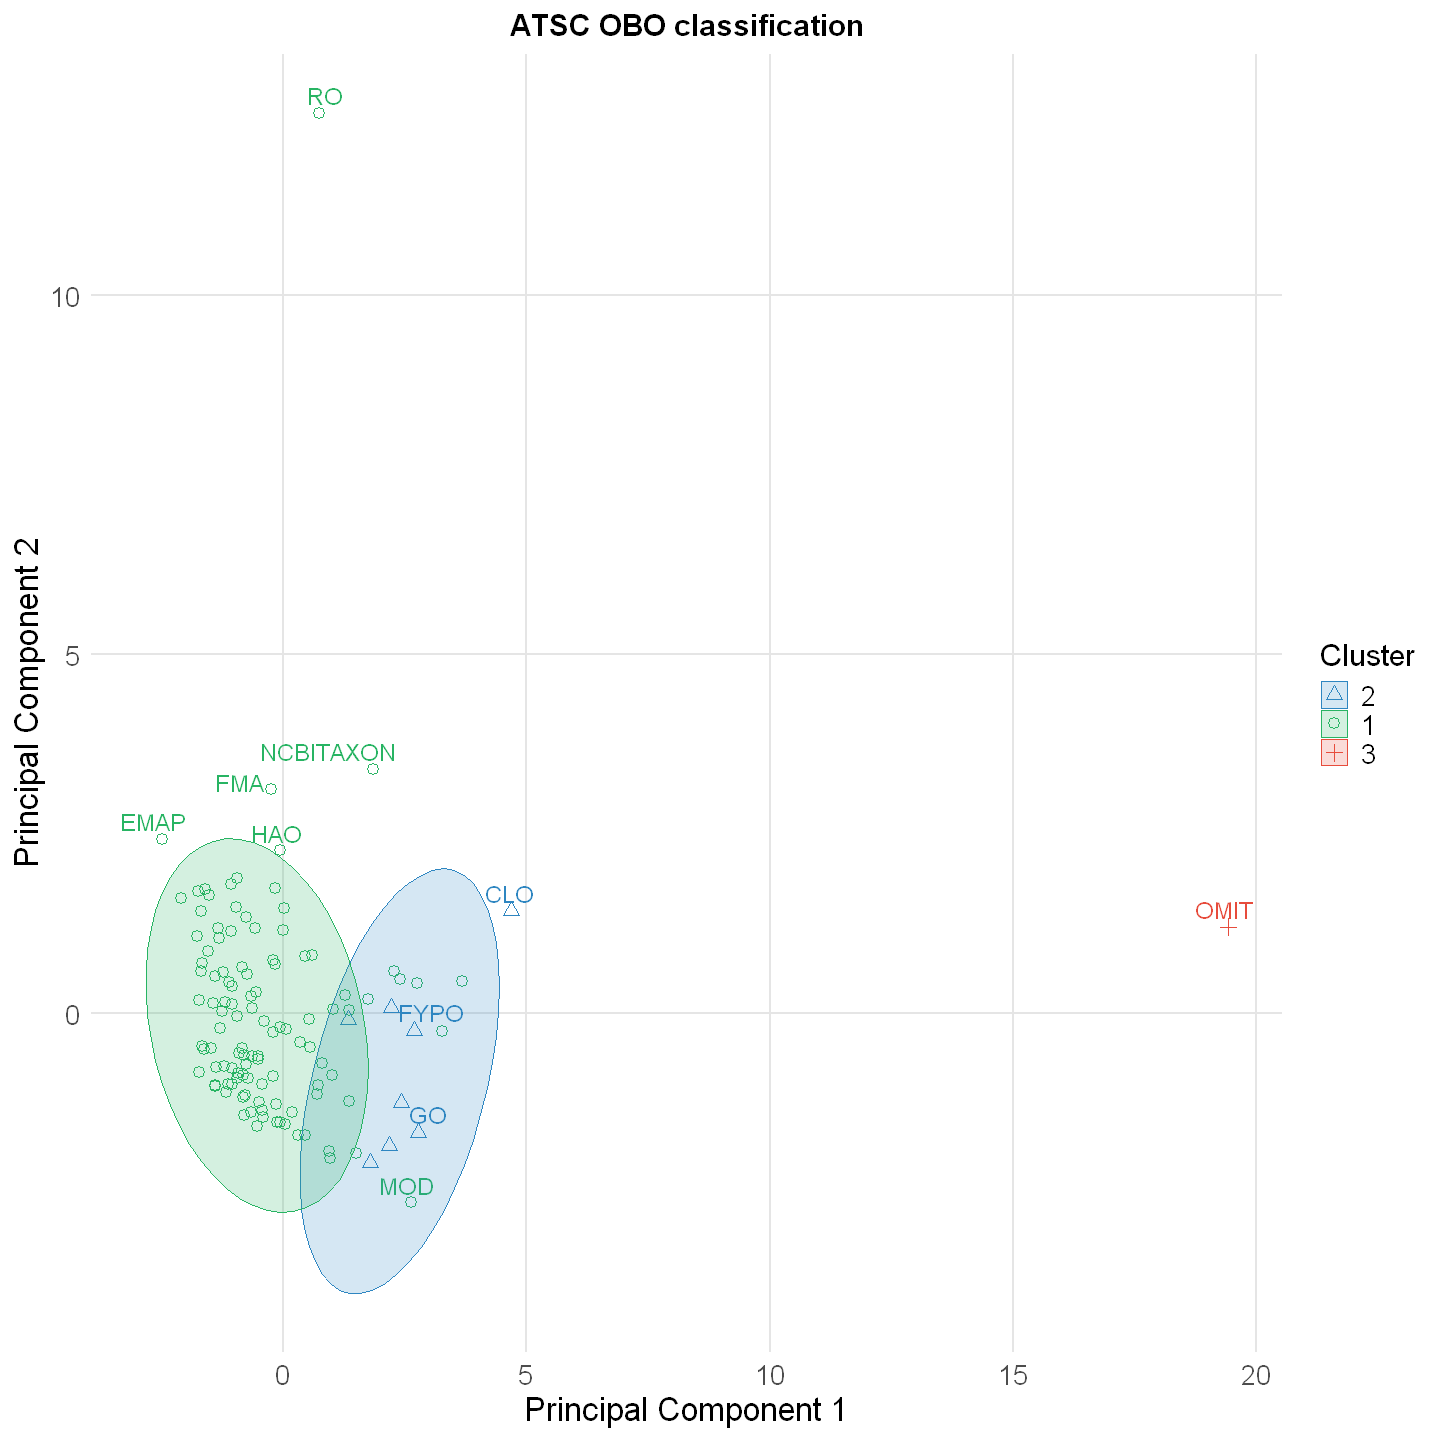

In [22]:
cluster_colors <- c("#2E86C1", "#28B463", "#E74C3C", "#9B59B6", "#F1C40F", "#7F8C8D", 
            "#D35400", "#8E44AD", "#16A085")

cluster_shapes = unique(pca_df$Cluster)
cluster_labels = unique(pca_df$Cluster)

ggplot(pca_df, aes(x = Dim.1, y = Dim.2, shape = Cluster, color = Cluster, label = Description)) +
  geom_point(size = 3) +
  geom_text_repel(
    vjust = 1,
    hjust = 1,
    size = 5,
    show.legend = FALSE,
    point.padding = 0.4,
    box.padding = 0.25,
    max.overlaps = 5,
    segment.color = "grey70",
    segment.size = 0.2
  ) +
  stat_ellipse(aes(fill = Cluster, group = Cluster), level = 0.95, alpha = 0.2, geom = "polygon") +
  labs(
    title = "ATSC OBO classification",
    x = "Principal Component 1",
    y = "Principal Component 2"
  ) +
  scale_shape_manual(values = cluster_shapes, labels = unique(pca_df$Cluster)) +
  scale_color_manual(values = cluster_colors, labels = cluster_labels)  +
  scale_fill_manual(values = cluster_colors, labels = cluster_labels)   +
  theme_minimal(base_size = 15) +
  theme(
    plot.title = element_text(hjust = 0.5, size = 18, face = "bold"),
    axis.title.x = element_text(size = 20),
    axis.title.y = element_text(size = 20),
    axis.text = element_text(size = 16),
    legend.position = "right",
    legend.title = element_text(size = 18),
    legend.text = element_text(size = 16),
    panel.grid.major = element_line(color = "grey90"),
    panel.grid.minor = element_blank()
  )